# SAE 204 : BDD - Groupe

Dictionnaire des tables SQL

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


Tester la connexion avec la base de données

In [10]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Script 1 — Erreurs entre mesures manuelles et automatiques :

In [11]:
import psycopg


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT sensormeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
                FROM controlmeasurement
                JOIN sensormeasurement
                    ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = 1
                ORDER BY controltimestamp
                LIMIT 50;
            """)

            for row in cur.fetchall():
                print(f"Sensor {row[0]} | Difference: {row[1]}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_difference(conn_params)

Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.18043561924514262
Sensor 1 

Script 2 — Moyenne et écart-type :

In [12]:
import psycopg


def get_sensor_statistics(conn_params):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT sensorid,
                           AVG(sensorvalue) AS moyenne,
                           STDDEV(sensorvalue) AS ecart_type
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    GROUP BY sensorid;
                """)

                ligne = cur.fetchone()

                if ligne:
                    print(f"Sensor {ligne[0]} | Average: {ligne[1]:.10f} | StdDev: {ligne[2]:.10f}")
                else:
                    print("No data found for this sensor.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_statistics(conn_params)

Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289


Carte de contrôle

Moyenne : -0.0037443199 | Écart-type : 0.4127852187
Fenêtre : 8 jours → 33 points
Sélection : 8 jours (33 points)


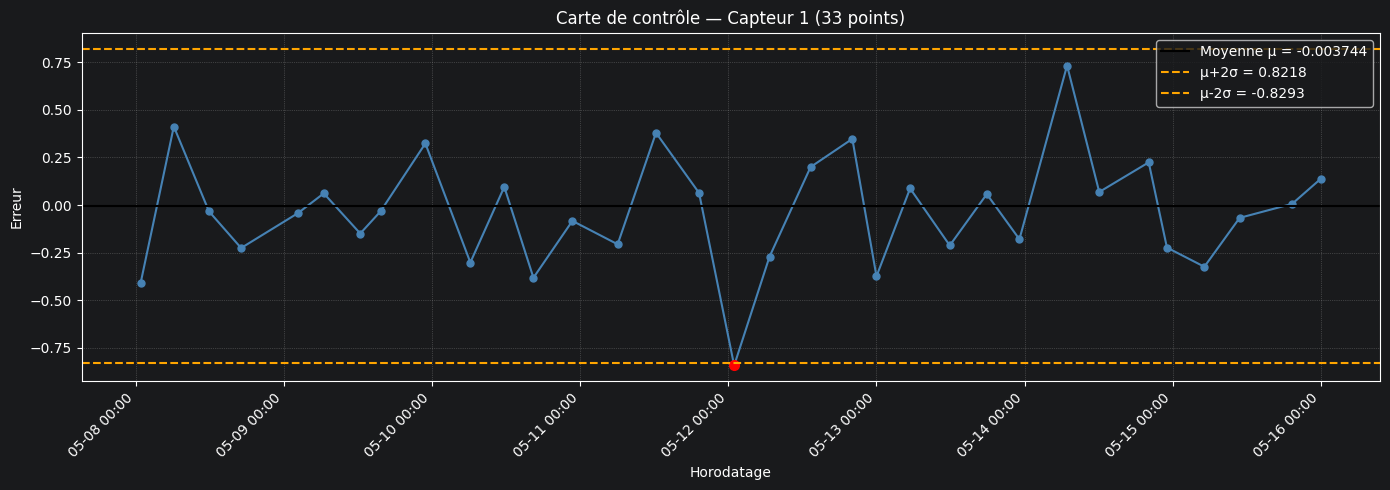

In [13]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)


def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connexion:
        curseur = connexion.cursor()
        curseur.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        moyenne, ecart_type = curseur.fetchone()

        if moyenne is None:
            return None, None

        print(f"Moyenne : {moyenne:.10f} | Écart-type : {ecart_type:.10f}")
        return float(moyenne), float(ecart_type)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connexion:
        curseur = connexion.cursor()

        for jours in [8, 30, 90, 180, 365]:
            curseur.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, jours, SENSOR_ID, MAX_POINTS))

            lignes = curseur.fetchall()
            print(f"Fenêtre : {jours} jours → {len(lignes)} points")

            if len(lignes) >= MIN_POINTS:
                lignes.reverse()
                print(f"Sélection : {jours} jours ({len(lignes)} points)")
                return lignes

        lignes.reverse()
        return lignes


def plot_chart(donnees, moyenne, ecart_type):
    temps = [ligne[2] for ligne in donnees]
    erreurs = [float(ligne[1]) for ligne in donnees]

    figure, axe = plt.subplots(figsize=(14, 5))
    axe.plot(temps, erreurs, marker='o', linestyle='-', color='steelblue', markersize=5)

    for temps_i, erreur_i in zip(temps, erreurs):
        if not (moyenne - 2 * ecart_type <= erreur_i <= moyenne + 2 * ecart_type):
            axe.plot(temps_i, erreur_i, 'ro', markersize=7)

    axe.axhline(moyenne, color='black', linewidth=1.5, label=f'Moyenne µ = {moyenne:.6f}')
    axe.axhline(moyenne + 2 * ecart_type, color='orange', linestyle='--', label=f'µ+2σ = {moyenne + 2 * ecart_type:.4f}')
    axe.axhline(moyenne - 2 * ecart_type, color='orange', linestyle='--', label=f'µ-2σ = {moyenne - 2 * ecart_type:.4f}')

    axe.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axe.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axe.set_title(f'Carte de contrôle — Capteur {SENSOR_ID} ({len(donnees)} points)')
    axe.set_xlabel('Horodatage')
    axe.set_ylabel('Erreur')
    axe.legend()
    axe.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    moyenne, ecart_type = get_sensor_statistics(conn_params)
    donnees = get_sensor_difference(conn_params)

    if donnees and moyenne is not None:
        plot_chart(donnees, moyenne, ecart_type)
    else:
        print("Impossible de tracer le graphique : données manquantes ou insuffisantes.")

Script 3 : Histogramm

In [14]:
import psycopg


def take_avg_gap(conn_params):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT sensorid,
                           AVG(sensorvalue) AS moyenne,
                           STDDEV(sensorvalue) AS ecart_type
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    GROUP BY sensorid;
                """)

                ligne = cur.fetchone()

                if ligne:
                    print(f"Sensor {ligne[0]} | Average: {ligne[1]:.10f} | StdDev: {ligne[2]:.10f}")
                    borne_basse = ligne[1] - ligne[2]
                    borne_haute = ligne[1] + ligne[2]
                    cur.execute("""SELECT COUNT(*) FROM sensormeasurement WHERE sensorid = 1""")
                    total = cur.fetchone()[0]
                    cur.execute("""
                    SELECT COUNT(*)
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    AND sensorvalue BETWEEN %s AND %s""", (borne_basse, borne_haute))
                    resultat = cur.fetchone()
                    pourcentage = (resultat[0] / total) * 100
                    print(f"Points dans [μ-σ, μ+σ] : {resultat[0]} / {total} → {pourcentage:.2f} %")
                else:
                    print("No data found for this sensor.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    take_avg_gap(conn_params)

Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289
Points dans [μ-σ, μ+σ] : 5753954 / 8657281 → 66.46 %
